In [16]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

# 记录开始时间
start_time = time.time()

# 定义超参数
batch_size = 64
learning_rate = 0.001
num_epochs = 100

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
image_datasets = datasets.ImageFolder(data_dir, data_transforms)

# 划分训练集和测试集
train_data, test_data = train_test_split(image_datasets, test_size=0.3, random_state=42)

dataloaders = {'train':torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4),
               'val':torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)}
dataset_sizes = {'train': len(train_data),'val': len(test_data)}

In [ ]:
train_class_counts = {class_label: 0 for class_label in range(len(image_datasets.classes))}
for data in train_data:
    label = data[1]
    train_class_counts[label] += 1

test_class_counts = {class_label: 0 for class_label in range(len(image_datasets.classes))}
for data in test_data:
    label = data[1]
    test_class_counts[label] += 1

print("训练集中每个类别的图像数量:")
for class_label, count in train_class_counts.items():
    print(f"Class {class_label}: {count}")

print("测试集中每个类别的图像数量:")
for class_label, count in test_class_counts.items():
    print(f"Class {class_label}: {count}")

In [17]:
# 加载预训练模型
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0')
model = model.to(device)

# 冻结前8个层
for param in model.conv1.parameters():
    param.requires_grad = False

for param in model.bn1.parameters():
    param.requires_grad = False

for param in model.layer1.parameters():
    param.requires_grad = False

# for param in model.layer2.parameters():
#     param.requires_grad = False

# for param in model.layer3.parameters():
#     param.requires_grad = False

# for param in model.layer4.parameters():
#     param.requires_grad = False

# for param in model.avgpool.parameters():
#     param.requires_grad = False

# for param in model.fc.parameters():
#     param.requires_grad = False

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), 
                      lr=learning_rate, momentum=0.9)

# 训练模型
result = {
          "acu_train": [],
          "acu_test": [],
          "loss_train":[],
          "recall": []
          }
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            
#             print(phase,'epoch',":",epoch,'num_imputs',inputs.size())
#             tensor = inputs[0].to(torch.float32).cpu()
#             print(labels[0])
#             # 将张量转换为图像并显示
#             plt.imshow(tensor.permute(1, 2, 0))
#             plt.show()
            
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        
        if phase=='train':
            result["acu_train"].append('{:.4f}'.format(epoch_acc))
            result["loss_train"].append('{:.4f}'.format(epoch_loss))
        elif phase=='val':
            result["acu_test"].append('{:.4f}'.format(epoch_acc))
            recall = recall_score(labels.data.detach().cpu().numpy(), preds.detach().cpu().numpy(), average="macro")
            result["recall"].append(recall)

        print('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}'.format(epoch, phase, epoch_loss, epoch_acc))
        with open('C:/Users/WHS/Desktop/Dual-ResNet18-SVM/result/result_file_d1.txt', "a") as file:
            file.write('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}\n'.format(epoch, phase, epoch_loss, epoch_acc))

epoch: 0, train Loss: 1.4059 Acc: 0.3295
epoch: 0, val Loss: 1.3657 Acc: 0.3063
epoch: 1, train Loss: 0.9437 Acc: 0.6860
epoch: 1, val Loss: 1.3529 Acc: 0.2928
epoch: 2, train Loss: 0.6084 Acc: 0.8411
epoch: 2, val Loss: 1.1750 Acc: 0.4820
epoch: 3, train Loss: 0.4134 Acc: 0.9012
epoch: 3, val Loss: 0.7374 Acc: 0.7793
epoch: 4, train Loss: 0.3114 Acc: 0.9438
epoch: 4, val Loss: 0.5337 Acc: 0.8423
epoch: 5, train Loss: 0.2122 Acc: 0.9767
epoch: 5, val Loss: 0.3808 Acc: 0.8829
epoch: 6, train Loss: 0.1651 Acc: 0.9845
epoch: 6, val Loss: 0.2966 Acc: 0.9189
epoch: 7, train Loss: 0.1534 Acc: 0.9690
epoch: 7, val Loss: 0.2913 Acc: 0.9189
epoch: 8, train Loss: 0.1244 Acc: 0.9787
epoch: 8, val Loss: 0.2141 Acc: 0.9550
epoch: 9, train Loss: 0.1077 Acc: 0.9922
epoch: 9, val Loss: 0.2050 Acc: 0.9279
epoch: 10, train Loss: 0.0727 Acc: 0.9961
epoch: 10, val Loss: 0.2163 Acc: 0.9189
epoch: 11, train Loss: 0.0655 Acc: 0.9961
epoch: 11, val Loss: 0.2188 Acc: 0.9234
epoch: 12, train Loss: 0.0570 Acc: 0

In [18]:
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time)

361.01717925071716


In [4]:
torch.save(model.state_dict(), 'resnet18.pth')

In [28]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split
start_time = time.time()
data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms) for x in ['train', 'val']}
test_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=64, shuffle=True, num_workers=4)

model = models.resnet18()
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0')
model = model.to(device)

# 加载之前保存的模型参数
model.load_state_dict(torch.load('C:/Users/WHS/Desktop/Dual-ResNet18-SVM/result/resnet18_d2.pth'))
for inputs, labels in test_loader:    
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    print(labels,preds)
    break
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(labels))

tensor([1, 1, 0, 2, 3, 0, 3, 1, 3, 2, 3, 1, 1, 3, 3, 0, 1, 3, 3, 3, 0, 3, 2, 1,
        1, 0, 2, 0, 1, 2, 1, 0, 0, 2, 1, 3, 1, 2, 3, 0, 0, 3, 2, 2, 2, 2, 1, 2,
        0, 3, 2, 2, 3, 3, 1, 3, 3, 2, 1, 0, 1, 1, 3, 3], device='cuda:0') tensor([1, 1, 0, 2, 3, 0, 3, 3, 3, 2, 3, 1, 1, 3, 3, 0, 1, 3, 3, 3, 0, 3, 2, 1,
        0, 0, 2, 0, 0, 2, 1, 0, 0, 2, 1, 3, 1, 2, 3, 0, 0, 3, 2, 2, 2, 2, 3, 2,
        0, 0, 2, 2, 3, 3, 1, 0, 3, 2, 1, 0, 1, 1, 0, 3], device='cuda:0')
0.04385364055633545


In [2]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt

result = pd.DataFrame(result)
plt.figure()
# 设置字体为 Times New Roman
matplotlib.rcParams['font.family'] = 'Times New Roman'
result["acu_train"].astype(float).plot(label='acu_train')
result["loss_train"].astype(float).plot(label='loss_train')
result["acu_test"].astype(float).plot(label='acu_test')
result["recall"].astype(float).plot(label='recall')
plt.xlabel('Epochs')
plt.ylabel('Loss / Accuracy')
plt.xlim(0,100)
plt.ylim(0,1.5)
plt.legend(loc='upper right',prop={'size': 18})
# 设置边框刻度线内置
plt.tick_params(direction='in')
fig = plt.gcf()
fig.set_size_inches(5, 4)
fig.savefig('resnet18_d0_acu.png', dpi=300)
plt.show()

NameError: name 'result' is not defined

In [29]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    matplotlib.rcParams['font.size'] = 18
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('resnet18_d0_con.png', dpi=300)
    plt.tight_layout()

In [30]:
labels = labels.cpu()
preds = preds.cpu()
cnf_matrix = confusion_matrix(labels.data, preds)
print(cnf_matrix)

[[12  0  0  0]
 [ 2 13  0  2]
 [ 0  0 15  0]
 [ 3  0  0 17]]


Normalized confusion matrix
[[1.         0.         0.         0.        ]
 [0.11764706 0.76470588 0.         0.11764706]
 [0.         0.         1.         0.        ]
 [0.15       0.         0.         0.85      ]]


<ipython-input-29-671984465e85>:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


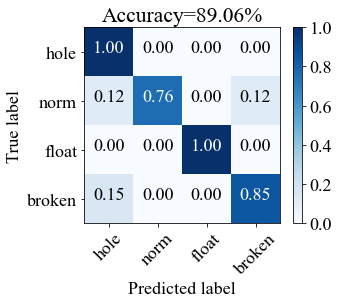

In [31]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(labels.data, preds)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)